# Example 10: Kernel Ridge Regression as an Example of RKHS

Kernel functions come into play in the context of smoothing methods and penalized regression methods. One should think of kernel functions as an umbrella term that encompasses several techniques. Here, we focus on Reproducing Kernel Hilbert Spaces (RKHS), which are special spaces constructed from a kernel function and contains a set of solutions based on that function.

As was stated in class, Kernel functions transform data into a higher-dimensional space, enabling linear methods to capture non-linear relationships. Reproducing Kernel Hilbert Spaces are the mathematical setting where these transformations happen. In RKHS, functions rather than data points are the focus, and kernel functions are used to define an inner product. 

There are several example of such kernel methods. In this example, we look at kernel ridge regression. Kernel functions in the context of ridge regression allow for a linear model to capture nonlinear patterns. This is because of the **kernel trick**, which allows for us to consider the feature vector $\Phi(\bf x_i)$ over the actual data $\bf x_i$. 

If you refer back to ridge regression, we know the weights of the linear model are found with the equation 
$$ \bf \hat \beta = (\bf X^T \bf X + \lambda \bf I)^{-1} \bf X^T \bf y $$
Under the context of the kernel trick, this equation is transformed using the feature vector: 
$$ \hat \beta = \Phi( \Phi^T \Phi + \lambda \bf I)^{-1} \bf y $$ which can be rewritten as 
$$\bf \hat \beta = \sum_{i} \alpha_i \Phi(\bf x_i)$$ where $$\bf \alpha = (\Phi ^T \Phi + \lambda \bf I)^{-1} \bf y.$$

The confusing thing in all of this to students who have not had strong backgrounds in linear algebra or functional analysis is this switch between thinking of objects like $\Phi$ as both a function and a matrix. But matrices are functions as they map vectors to other vectors. And even if we are working in infinite dimensions (which is a possibility here depending on $\Phi$), this correspondence can still work. 

The important concept to know is that the mathematics works the same and the only thing we need to understand is the kernel $$K(x, w) = \sum_{i} a_i \Phi(x_i) \Phi(w_i).$$ The result is that we can use a seemlingly linear technique for nonlinear relationships. 

We, luckily, do not have to delve deep into the mathematics to program this. 

## KernelRidge in Scikit-learn with RBF Kernel

`KernelRidge` in scikit-learn extends Ridge Regression by incorporating kernel tricks. This enables the model to operate in a high-dimensional feature space without explicitly computing the coordinates of the data in that space.

It's particularly useful for small to medium-sized datasets and can handle a range of regression and (pseudo) classification problems.

The kernel we will use is the **Radial Basis Function**, denoted RBF. This is one of several popular kernels. 

The RBF kernel function, often represented as $$\phi(x) = e^{-(\gamma \|x\|)^2}$$, is characterized by its Gaussian-like shape, where $\gamma$ is a parameter that controls the width of the Gaussian.

This means when we implement `KernelRidge` with the `RBF` kernel, we are managing two hyperparameters: the regularization parameter $\lambda$ and $\gamma$.

## Other Examples: 

There are several RKHS examples beyond kernel ridge, including  
- **Support Vector Machines** (nearly identical to kernel ridge), and 
- **Kernel Principal Component Analysis**.

In [39]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# Imports for model and evaluation
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

Here, we perform this technique on the dataset with the ground truth 
$$Y = \sin(X) + \epsilon$$

In [146]:
# Generate synthetic data
np.random.seed(10)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
Y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

X_range = np.linspace(0, 5, 250)
Y_true = np.sin(X_range) # To plot the ground truth at the end for comparison

# Split the data into training, validation, and testing sets
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=10)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=10)

# For fitting the function once hyperparameters are selected
X_train_val = np.concatenate((X_train, X_val))
Y_train_val = np.concatenate((Y_train, Y_val))

Let's plot the full dataset. 

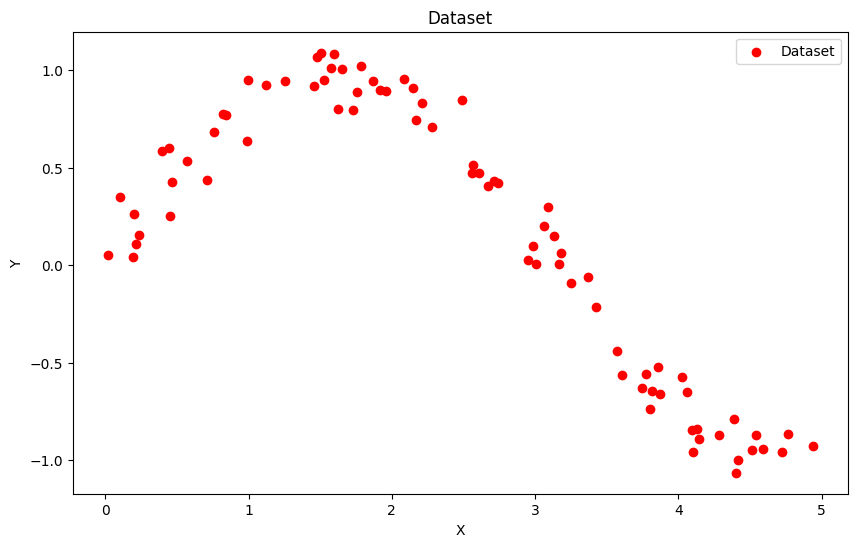

In [147]:
# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='red', label='Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset')
plt.legend()
plt.show()

We can see that this is clearly a nonlinear dataset. Traditional ridge regression would attempt to fit a straight line to this data, controlling for the size of the coefficients. With kernel ridge regression, we will be able to transform the data using the RBF kernel. 

Below, we search for optimal hyperparameters and test them against the mean squared error of the validation set. 

In [134]:
# Define a range of hyperparameters
# Rounded to avoid floating point error
lambdas = np.round(np.arange(0.1, 4, 0.1), 1)
gammas = np.round(np.arange(0.1, 4, 0.1), 1) 

# Use itertools.product for Cartesian product
lam_and_gam = list(itertools.product(lambdas, gammas))

# Initialize lists to store MSE values for training and validation
mse_train = []
mse_val = []

# Loop through different alpha values and fit the model
for lam, gam in lam_and_gam:
    
    # Create and fit the RKHS-based Kernel Ridge Regression model
    kr = KernelRidge(kernel='rbf', alpha=lam, gamma=gam)
    kr.fit(X_train, Y_train)
    
    # Calculate Mean Squared Error for validation set
    Y_val_pred = kr.predict(X_val)
    mse_val.append(mean_squared_error(Y_val, Y_val_pred))

# Find hyperparameters with the lowest validation MSE
lowest_mse = min(mse_val)
best_lambda = lam_and_gam[np.argmin(mse_val)][0]
best_gamma = lam_and_gam[np.argmin(mse_val)][1]

print(f"The lowest MSE is {lowest_mse}; " + 
      f"associated to lambda = {best_lambda} and gamma = {best_gamma}")


The lowest MSE is 0.01019588284894625; associated to lambda = 0.1 and gamma = 0.6


Let's graph the mean squared error values against the two parameters. Because that requires three dimensions, we look at a contour plot of the MSE values. The smalled MSE value, associated to our selected choices of $\lambda$ and $\gamma$, is highlighted in red. 

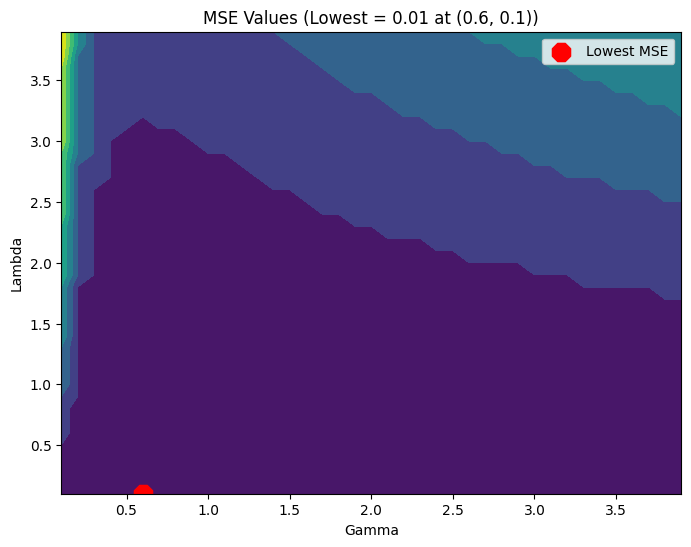

In [154]:
# Create a grid for mse_vals
mse_grid = np.full((len(lambdas), len(gammas)), np.nan)

# Fill the grid with mse_vals
for (lam, gam), mse in zip(lam_and_gam, mse_val):
    lam_index = np.where(lambdas == lam)[0][0]
    gam_index = np.where(gammas == gam)[0][0]
    mse_grid[lam_index, gam_index] = round(mse, 2)

# Plotting the MSE against gammas and lambdas
plt.figure(figsize=(8, 6))
plt.contourf(gammas, lambdas, mse_grid, cmap='viridis')
# Highlight the minimum value location
plt.scatter([best_gamma], [best_lambda], color='red', s=200, marker='8', label="Lowest MSE")
plt.xlabel('Gamma')
plt.ylabel('Lambda')
plt.title(f'MSE Values (Lowest = {round(lowest_mse, 3)} at {(best_gamma, best_lambda)})')
plt.legend()
plt.show()

With the hyperparameters selected, we can construct our final model. 

In [155]:
# Fit the final model using the best alpha on the training and validation sets
final_model = KernelRidge(kernel='rbf', alpha=best_lambda, gamma=best_gamma)
final_model.fit(X_train_val, Y_train_val)

KernelRidge(alpha=0.1, gamma=0.6, kernel='rbf')

We can now measure the efficacy of our final model against the testing set. 

In [156]:
# Predict on the test set using the final model
Y_test_pred = final_model.predict(X_test)

# Calculate Mean Squared Error and R-squared for the test set
mse_test = mean_squared_error(Y_test, Y_test_pred)
r2_test = r2_score(Y_test, Y_test_pred)

# Print the best alpha and test set evaluation metrics
print(f"Test Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Test R-squared (R2): {r2_test:.4f}")

Test Mean Squared Error (MSE): 0.0112
Test R-squared (R2): 0.9804


We can plot our final model against our dataset. Because this is synthetic data, we can compare it with the ground truth to get a sense of how well we did. 

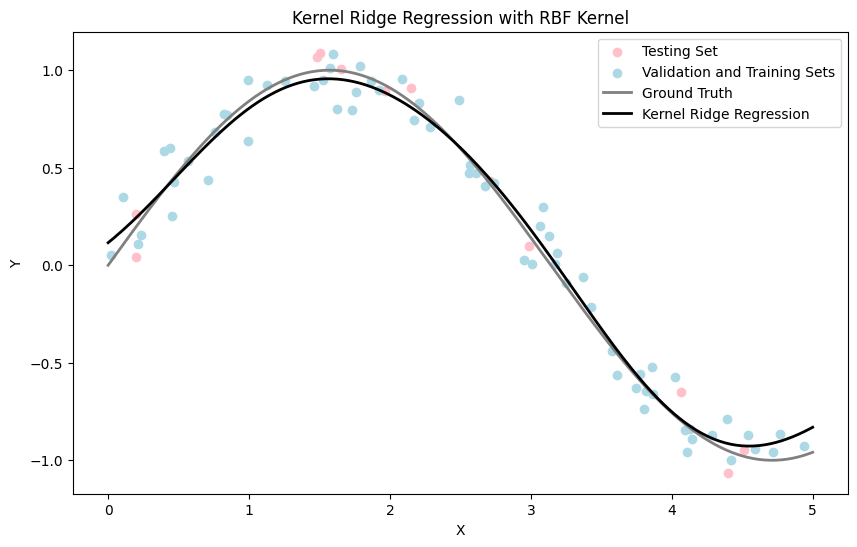

In [157]:
Y_plot = final_model.predict(X_range.reshape(-1, 1))

# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, Y_test, color='pink', label='Testing Set')
plt.scatter(X_train_val, Y_train_val, color='lightblue', label='Validation and Training Sets')
plt.plot(X_range, Y_true, color='grey', lw=2, label='Ground Truth')
plt.plot(X_range, Y_plot, color='black', lw=2, label='Kernel Ridge Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Kernel Ridge Regression with RBF Kernel')
plt.legend()
plt.show()